# Spatial maps for the main manuscript

Explore how participant groups and proposals are positioned in the fitted maps. This notebook produces Figures 3–5 and S10–S12, and panel 2c.

**Inputs:** coordinates, participant metadata, proposal labels, and TrueSkill rankings in `data/processed/figure_inputs/spatial`. These files are included and are regenerated by notebook 09 from notebooks 01–03 and 06. **Outputs:** PDFs in `outputs/figures`, panel 2c in `outputs/panels`, and participant-level plotting data and group summaries in `outputs/tables/spatial`.

**Run or explore:** run top to bottom in a fresh kernel. No previous notebook execution or model fitting is required with the bundled inputs. Sample definitions, the density estimator, and plot settings are visible below. Density evaluation is the slowest step.

The countries were fitted separately. Their panels describe within-country organization and do not establish comparable levels of polarization across countries. Ideological labels orient and interpret the displays after estimation.


In [1]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("png")


## Setup and included inputs

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
assert (ROOT / "data/raw").is_dir(), "Open from the project root or notebooks directory."

assert (
    ROOT / "data/processed/figure_inputs/spatial"
).is_dir(), "Run from the project root or notebooks directory."
DATA = ROOT / "data/processed/figure_inputs/spatial"
OUT = ROOT / "outputs" / "tables" / "spatial"
FIG = ROOT / "outputs" / "figures"
PANELS = ROOT / "outputs" / "panels"
DIAG = ROOT / "outputs" / "diagnostics"
for directory in [OUT, FIG, PANELS, DIAG]:
    directory.mkdir(parents=True, exist_ok=True)
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "pdf.fonttype": 42,
        "figure.facecolor": "white",
        "savefig.facecolor": "white",
    }
)
COLORS = {"Left": "#D55E00", "Right": "#0072B2"}
STYLES = {"Left": "-", "Right": "--"}
CONTOUR_MASSES = [0.95, 0.80, 0.50]
DENSITY_FILL_ALPHA = 0.07
COUNTRIES = ["Chile", "France", "Brazil"]
COHORTS = ["Silent Generation", "Baby Boomers", "Generation X", "Generation Y", "Generation Z"]
coordinates, metadata = {}, {}
for country in COUNTRIES:
    key = "uuid" if country == "Chile" else "user_id"
    coordinates[country] = pd.read_csv(DATA / f"{country}_coordsU.csv").rename(
        columns={key: "participant_id"}
    )
    metadata[country] = pd.read_csv(DATA / f"{country}_metadata.csv").rename(
        columns={key: "participant_id"}
    )
    assert coordinates[country].participant_id.is_unique
    assert coordinates[country].participant_id.notna().all()
    assert np.isfinite(coordinates[country][["z1", "z2"]]).all().all()


## Construct one-person samples for each analysis

Repeated identical responses are collapsed. For overall maps, a participant is excluded only if valid responses place them on both sides. A neutral or missing response is not assigned a side. Sex and cohort panels then require consistency in their additional variables.

The cohort calculation uses reported age and participation year to estimate birth year. It checks birth-year consistency rather than choosing a convenient timestamp. These analysis-specific rules avoid giving people with repeated questionnaires more weight.


In [3]:
# Binary coding matches the original analysis. Neutral/missing responses are
# outside these plots. A person with conflicting eligible binary labels is
# excluded; repeated labels on the same side do not add weight.
sample_rows, samples = [], {}
for country in COUNTRIES:
    meta = metadata[country].copy()
    valid_left = list(range(5)) if country == "Chile" else [1, 2]
    valid_right = list(range(6, 11)) if country == "Chile" else [4, 5]
    meta["side"] = np.where(
        meta.politica.isin(valid_left),
        "Left",
        np.where(meta.politica.isin(valid_right), "Right", None),
    )
    linked = coordinates[country].merge(meta, on="participant_id", validate="one_to_many")
    selected = linked[linked.side.notna()].copy()
    unique = selected[["participant_id", "z1", "z2", "side"]].drop_duplicates()
    conflicts = unique.groupby("participant_id").side.nunique()
    conflict_ids = conflicts[conflicts > 1].index
    clean = unique[~unique.participant_id.isin(conflict_ids)].copy()
    assert clean.participant_id.is_unique
    samples[(country, "overall")] = clean
    sample_rows.append(
        {
            "country": country,
            "analysis": "overall",
            "linked_binary_rows": len(selected),
            "eligible_unique_ids": selected.participant_id.nunique(),
            "conflicting_ids_excluded": len(conflict_ids),
            "retained_ids": len(clean),
            "left": int((clean.side == "Left").sum()),
            "right": int((clean.side == "Right").sum()),
        }
    )


## Chilean sex and cohort samples

These panels add the required demographic field to the binary sample checks. A response can therefore be eligible for the overall map but absent from a demographic panel.


In [4]:
# Sex panels retain the two categories displayed in the source figure. Other
# sex responses remain eligible for analyses that do not use sex.
chile = coordinates["Chile"].merge(
    metadata["Chile"], on="participant_id", validate="one_to_many"
)
chile["side"] = np.where(
    chile.politica.isin(range(5)),
    "Left",
    np.where(chile.politica.isin(range(6, 11)), "Right", None),
)
binary = chile[chile.side.notna()].copy()
sex_rows = binary[binary.sex.isin(["Masculino", "Femenino", "Otro"])].copy()
sex_unique = sex_rows[["participant_id", "z1", "z2", "side", "sex"]].drop_duplicates()
conflict = sex_unique.groupby("participant_id")[["side", "sex"]].nunique().gt(1).any(axis=1)
sex_conflict_ids = conflict[conflict].index
sex_clean = sex_unique[~sex_unique.participant_id.isin(sex_conflict_ids)].copy()
assert sex_clean.participant_id.is_unique
samples[("Chile", "sex")] = sex_clean
sample_rows.append(
    {
        "country": "Chile",
        "analysis": "sex",
        "linked_binary_rows": len(sex_rows),
        "eligible_unique_ids": sex_rows.participant_id.nunique(),
        "conflicting_ids_excluded": len(sex_conflict_ids),
        "retained_ids": len(sex_clean),
        "left": int((sex_clean.side == "Left").sum()),
        "right": int((sex_clean.side == "Right").sum()),
    }
)


### Cohort assignment

The ordered birth-year bins below are the cohort definitions used in the manuscript. Rows outside these bins or with conflicting birth years are not assigned arbitrarily.


In [5]:
# Cohorts use birth year = participation year minus age, as in the source.
# Consistent birth years are collapsed even when timestamps differ. No date or
# age response is selected arbitrarily. The original ordered bins are retained.
cohort_rows = binary.copy()
cohort_rows["age"] = pd.to_numeric(cohort_rows.age, errors="coerce")
cohort_rows["participation_year"] = pd.to_datetime(
    cohort_rows.datetime, errors="coerce", format="mixed"
).dt.year
cohort_rows = cohort_rows[
    cohort_rows.age.between(19, 120) & cohort_rows.participation_year.notna()
].copy()
cohort_rows["birth_year"] = cohort_rows.participation_year - cohort_rows.age
cohort_unique = cohort_rows[
    ["participant_id", "z1", "z2", "side", "birth_year"]
].drop_duplicates()
conflict = (
    cohort_unique.groupby("participant_id")[["side", "birth_year"]].nunique().gt(1).any(axis=1)
)
cohort_conflict_ids = conflict[conflict].index
cohort_clean = cohort_unique[~cohort_unique.participant_id.isin(cohort_conflict_ids)].copy()
assert cohort_clean.participant_id.is_unique
cohort_clean["cohort"] = pd.cut(
    cohort_clean.birth_year,
    bins=[1927, 1948, 1964, 1981, 1994, 2009],
    labels=COHORTS,
    right=True,
)
cohort_clean = cohort_clean[cohort_clean.cohort.notna()].copy()
samples[("Chile", "cohort")] = cohort_clean
sample_rows.append(
    {
        "country": "Chile",
        "analysis": "cohort",
        "linked_binary_rows": len(cohort_rows),
        "eligible_unique_ids": cohort_rows.participant_id.nunique(),
        "conflicting_ids_excluded": len(cohort_conflict_ids),
        "retained_ids": len(cohort_clean),
        "left": int((cohort_clean.side == "Left").sum()),
        "right": int((cohort_clean.side == "Right").sum()),
    }
)
sample_counts = pd.DataFrame(sample_rows)
display(sample_counts)
sample_counts.to_csv(DIAG / "spatial_sample_counts.csv", index=False)
for (country, analysis), frame in samples.items():
    display(frame)
    frame.to_csv(OUT / f"{country}_{analysis}_participants.csv", index=False)


,country,analysis,linked_binary_rows,eligible_unique_ids,conflicting_ids_excluded,retained_ids,left,right
0,Chile,overall,25075,22071,28,22043,12473,9570
1,France,overall,852,813,0,813,668,145
2,Brazil,overall,535,499,0,499,377,122
3,Chile,sex,25075,22071,37,22034,12467,9567
4,Chile,cohort,25075,22071,28,22043,12473,9570


,participant_id,z1,z2,side
0,000057c7-295c-4a61-8f62-76aff62bf079,0.620236,0.677677,Right
2,00032199-2183-48c0-8f0d-ac37dc8ece60,0.143278,0.733773,Right
4,000629ba-44c0-47c1-b2b2-abe4f0ee808f,0.287662,0.412808,Left
5,0006b923-77a6-40c1-95e0-f98b817bcab2,0.262506,0.210308,Left
6,00097f0b-7b32-4962-9780-1ca10ece1571,0.369477,0.271307,Right
...,...,...,...,...
42458,ffdd7eff-a598-4406-b445-ee1d7b61b039,0.520886,0.368498,Right
42462,fff04ade-6ae3-4a80-99ff-446a8bec535d,0.359187,0.410472,Right
42466,fff8a6be-746b-4d24-9148-73c8c6accb69,0.218051,0.444988,Left
42468,fffcdf0e-0c78-40f7-915a-d41d6650c99b,0.278650,0.946591,Left


,participant_id,z1,z2,side
0,001b18de-e566-4b13-9cf3-33e22e32be2a,0.638296,2.742960e-01,Right
1,002323cc-f7bd-4c3b-b3a7-d909a4b48556,0.539659,3.823855e-01,Left
3,007fb7f8-afde-4779-8fd9-191083118401,0.758623,4.740771e-07,Left
5,00adaa11-da32-4ad3-8377-bb6c69bf98c3,0.693660,5.414791e-03,Left
6,0179b686-baf9-4b09-a4aa-945877fd51aa,0.750049,4.562278e-07,Left
...,...,...,...,...
1174,fecf3440-84f3-4bcb-b2c4-f6c939d80ec7,0.672341,1.193472e-04,Left
1176,fee0b44f-2122-4067-bf1d-ebe3320aed73,0.821582,2.570344e-03,Left
1177,fefc6148-c16d-482c-a140-9594bc57a245,0.605513,1.054578e-01,Left
1178,ff332300-7340-44c6-a779-83ac1dc7b7f0,0.625281,1.152183e-02,Left


,participant_id,z1,z2,side
0,004ddaed-61da-408f-9030-79728dd9acfa,0.614649,0.329158,Left
1,008945db-7336-4b6f-80c8-67f6f760146a,0.603311,0.459762,Left
5,01e39de7-8a0a-4d1c-9d90-7678cc03a79c,0.414611,0.453049,Right
6,030b7184-640f-4e89-966e-51671d3071a1,0.651942,0.541494,Left
7,03139237-17ec-4e01-8883-c18097b396f9,0.640222,0.472652,Left
...,...,...,...,...
687,fd5859ab-7092-40b1-8abb-7ab3d566b138,0.716437,0.499555,Left
688,fd67377b-87eb-44e6-900b-68ebad9151cd,0.661909,0.487093,Left
691,fe041e5b-c584-4038-80fb-73f20fb1273c,0.548788,0.336800,Right
692,fe398646-1fde-4c97-b589-520b5186a428,0.364676,0.513142,Right


,participant_id,z1,z2,side,sex
0,000057c7-295c-4a61-8f62-76aff62bf079,0.620236,0.677677,Right,Masculino
2,00032199-2183-48c0-8f0d-ac37dc8ece60,0.143278,0.733773,Right,Masculino
4,000629ba-44c0-47c1-b2b2-abe4f0ee808f,0.287662,0.412808,Left,Masculino
5,0006b923-77a6-40c1-95e0-f98b817bcab2,0.262506,0.210308,Left,Masculino
6,00097f0b-7b32-4962-9780-1ca10ece1571,0.369477,0.271307,Right,Masculino
...,...,...,...,...,...
42458,ffdd7eff-a598-4406-b445-ee1d7b61b039,0.520886,0.368498,Right,Femenino
42462,fff04ade-6ae3-4a80-99ff-446a8bec535d,0.359187,0.410472,Right,Masculino
42466,fff8a6be-746b-4d24-9148-73c8c6accb69,0.218051,0.444988,Left,Masculino
42468,fffcdf0e-0c78-40f7-915a-d41d6650c99b,0.278650,0.946591,Left,Femenino


,participant_id,z1,z2,side,birth_year,cohort
0,000057c7-295c-4a61-8f62-76aff62bf079,0.620236,0.677677,Right,1992,Generation Y
2,00032199-2183-48c0-8f0d-ac37dc8ece60,0.143278,0.733773,Right,1986,Generation Y
4,000629ba-44c0-47c1-b2b2-abe4f0ee808f,0.287662,0.412808,Left,1989,Generation Y
5,0006b923-77a6-40c1-95e0-f98b817bcab2,0.262506,0.210308,Left,1973,Generation X
6,00097f0b-7b32-4962-9780-1ca10ece1571,0.369477,0.271307,Right,1991,Generation Y
...,...,...,...,...,...,...
42458,ffdd7eff-a598-4406-b445-ee1d7b61b039,0.520886,0.368498,Right,1993,Generation Y
42462,fff04ade-6ae3-4a80-99ff-446a8bec535d,0.359187,0.410472,Right,1985,Generation Y
42466,fff8a6be-746b-4d24-9148-73c8c6accb69,0.218051,0.444988,Left,1989,Generation Y
42468,fffcdf0e-0c78-40f7-915a-d41d6650c99b,0.278650,0.946591,Left,1984,Generation Y


## Figure 3: participant distributions along PC1

PCA is fitted to all unique participant coordinates in each country. Self-placement enters only when the sign is chosen for display, so that the left group has the lower median. This reflection does not change distances or explained variance.

Histogram weights divide by the full displayed binary sample. Thus each color's area reflects its share of participants, rather than forcing both groups to have equal area. The common y-axis does not make the independently learned horizontal scales comparable across countries.


,participant_id,z1,z2,side,PC1,country
0,000057c7-295c-4a61-8f62-76aff62bf079,0.620236,0.677677,Right,-0.052192,Chile
1,00032199-2183-48c0-8f0d-ac37dc8ece60,0.143278,0.733773,Right,-0.360209,Chile
2,000629ba-44c0-47c1-b2b2-abe4f0ee808f,0.287662,0.412808,Left,-0.012564,Chile
3,0006b923-77a6-40c1-95e0-f98b817bcab2,0.262506,0.210308,Left,0.143137,Chile
4,00097f0b-7b32-4962-9780-1ca10ece1571,0.369477,0.271307,Right,0.150640,Chile
...,...,...,...,...,...,...
23350,fd5859ab-7092-40b1-8abb-7ab3d566b138,0.716437,0.499555,Left,-0.162344,Brazil
23351,fd67377b-87eb-44e6-900b-68ebad9151cd,0.661909,0.487093,Left,-0.108036,Brazil
23352,fe041e5b-c584-4038-80fb-73f20fb1273c,0.548788,0.336800,Right,0.002505,Brazil
23353,fe398646-1fde-4c97-b589-520b5186a428,0.364676,0.513142,Right,0.189598,Brazil


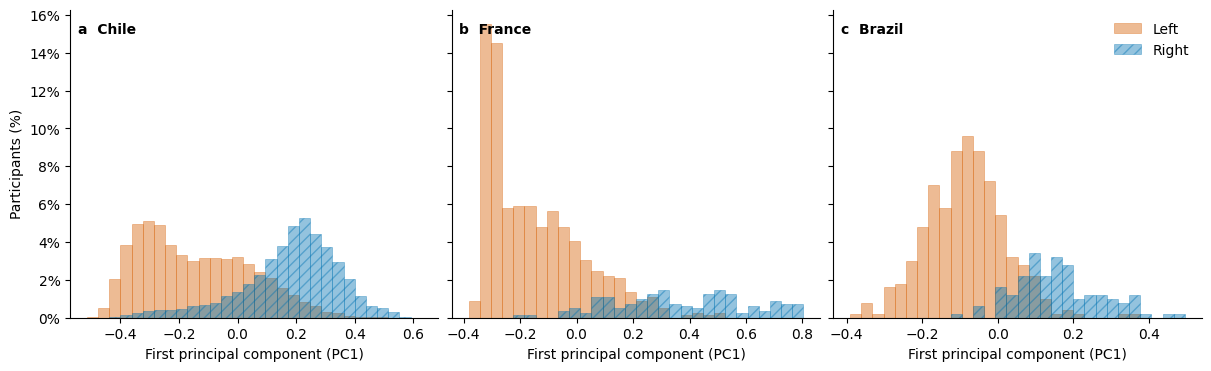

In [6]:
# PCA uses every unique coordinate in a country, before consulting labels.
# Its arbitrary sign is oriented left-to-right only for the display.
pc_frames = []
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True, layout="constrained")
for panel, (country, ax) in enumerate(zip(COUNTRIES, axes)):
    pca = PCA(n_components=1, svd_solver="full")
    pc = pca.fit_transform(coordinates[country][["z2", "z1"]]).ravel()
    projected = coordinates[country][["participant_id"]].assign(PC1=pc)
    plot_data = samples[(country, "overall")].merge(
        projected, on="participant_id", validate="one_to_one"
    )
    sign = (
        1
        if plot_data.loc[plot_data.side == "Left", "PC1"].median()
        < plot_data.loc[plot_data.side == "Right", "PC1"].median()
        else -1
    )
    plot_data["PC1"] *= sign
    plot_data["country"] = country
    pc_frames.append(plot_data)
    bins = np.histogram_bin_edges(plot_data.PC1, bins=30)
    for side in ["Left", "Right"]:
        values = plot_data.loc[plot_data.side == side, "PC1"]
        ax.hist(
            values,
            bins=bins,
            weights=np.ones(len(values)) / len(plot_data),
            color=COLORS[side],
            edgecolor=COLORS[side],
            alpha=0.42,
            hatch=None if side == "Left" else "///",
            label=side,
            linewidth=0.55,
        )
    ax.text(
        0.02,
        0.96,
        f"{chr(97+panel)}  {country}",
        transform=ax.transAxes,
        va="top",
        fontweight="bold",
    )
    ax.set_xlabel("First principal component (PC1)")
    ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
axes[0].set_ylabel("Participants (%)")
axes[-1].legend(frameon=False)
pc_data = pd.concat(pc_frames, ignore_index=True)
display(pc_data)
pc_data.to_csv(OUT / "pca_participants.csv", index=False)
display(fig)
fig.savefig(FIG / "Fig3.pdf", bbox_inches="tight")
plt.close(fig)


## Group summaries from a Gaussian density estimate

For each group, the code fits a Gaussian kernel density estimate (KDE) with Scott bandwidth on a 200 × 200 grid. The mean, coordinate-wise median, and density peak summarize different aspects of the same distribution. Their Euclidean separation is a descriptive within-fit comparison.

The density peak must be a unique interior maximum above the 90th density percentile. A boundary or tied maximum raises an error so the choice is inspected. Contours are drawn at thresholds containing approximately 95%, 80%, and 50% of the density mass on this grid. Sorting grid densities and accumulating their mass converts those proportions into contour heights.

The two functions below are local because the same estimator and drawing steps are reused for every group and several figures. They return objects or draw onto a supplied axis. They do not write files.


The display retains the same outer 95% region. A single pale fill and three contour lines reduce visual clutter without changing the KDE, its bandwidth or the estimated group summaries.

In [7]:
# Estimate Gaussian KDE with Scott bandwidth on a 200 x 200 grid. The peak
# must be a unique interior maximum above the 90th density percentile.
# A boundary or tied maximum raises an error instead of selecting one arbitrarily.
def density_and_summaries(frame):
    """Fit the group KDE and return its grid, mean, median, and unique peak."""
    xy = frame[["z2", "z1"]].to_numpy().T
    assert xy.shape[1] >= 3
    kde = gaussian_kde(xy, bw_method="scott")
    gx, gy = np.mgrid[xy[0].min() : xy[0].max() : 200j, xy[1].min() : xy[1].max() : 200j]
    density = kde(np.vstack([gx.ravel(), gy.ravel()])).reshape(gx.shape)
    peak_index = np.unravel_index(np.argmax(density), density.shape)
    assert all(0 < p < 199 for p in peak_index), ("boundary peak", peak_index)
    assert np.count_nonzero(density == density[peak_index]) == 1
    assert density[peak_index] > np.percentile(density, 90)
    summary = {
        "Mean": xy.mean(axis=1),
        "Median": np.median(xy, axis=1),
        "Density peak": np.array([gx[peak_index], gy[peak_index]]),
    }
    return {
        "x": gx,
        "y": gy,
        "density": density,
        "summaries": summary,
        "n": xy.shape[1],
        "bandwidth_factor": float(kde.factor),
    }


def draw_density(ax, result, side):
    """Draw fixed probability-mass contours from an already fitted density."""
    # Iso-proportion contour levels show the same fitted Gaussian density.
    values = np.sort(result["density"].ravel())[::-1]
    cumulative = np.cumsum(values) / values.sum()
    thresholds = np.unique(
        [
            values[min(np.searchsorted(cumulative, p), len(values) - 1)]
            for p in CONTOUR_MASSES
        ]
    )
    ax.contourf(
        result["x"],
        result["y"],
        result["density"],
        levels=[thresholds[0], result["density"].max() * (1 + 1e-8)],
        colors=[COLORS[side]],
        alpha=DENSITY_FILL_ALPHA,
    )
    ax.contour(
        result["x"],
        result["y"],
        result["density"],
        levels=thresholds,
        colors=[COLORS[side]],
        linestyles=STYLES[side],
        linewidths=np.linspace(0.55, 1.1, len(thresholds)),
        alpha=0.85,
    )


## Estimate densities for the groups used in the figures

Calculate each density once, then reuse it for the summary figures and the joint proposal map. The summary table reports group sizes and the three distances before plotting.


In [8]:
groups = {
    "All participants": samples[("Chile", "overall")],
    "Men": sex_clean[sex_clean.sex == "Masculino"],
    "Women": sex_clean[sex_clean.sex == "Femenino"],
}
groups.update({cohort: cohort_clean[cohort_clean.cohort == cohort] for cohort in COHORTS})
densities, summary_rows = {}, []
for group, frame in groups.items():
    print("Computing density:", group, flush=True)
    densities[group] = {
        side: density_and_summaries(frame[frame.side == side]) for side in ["Left", "Right"]
    }
    for method in ["Mean", "Median", "Density peak"]:
        left = densities[group]["Left"]["summaries"][method]
        right = densities[group]["Right"]["summaries"][method]
        summary_rows.append(
            {
                "group": group,
                "summary": method,
                "left_dimension_1": left[0],
                "left_dimension_2": left[1],
                "right_dimension_1": right[0],
                "right_dimension_2": right[1],
                "distance": float(np.linalg.norm(left - right)),
                "n_left": densities[group]["Left"]["n"],
                "n_right": densities[group]["Right"]["n"],
            }
        )
summaries = pd.DataFrame(summary_rows)
display(summaries)
summaries.to_csv(OUT / "separation_summaries.csv", index=False)
summaries.to_latex(
    OUT / "separation_summaries.tex", index=False, float_format="%.6f", escape=True
)


Computing density: All participants


Computing density: Men


Computing density: Women


Computing density: Silent Generation


Computing density: Baby Boomers


Computing density: Generation X


Computing density: Generation Y


Computing density: Generation Z


,group,summary,left_dimension_1,left_dimension_2,right_dimension_1,right_dimension_2,distance,n_left,n_right
0,All participants,Mean,0.544747,0.247715,0.276341,0.428739,0.323746,12473,9570
1,All participants,Median,0.560546,0.218553,0.244032,0.430916,0.381155,12473,9570
2,All participants,Density peak,0.669561,0.111184,0.226093,0.429218,0.545720,12473,9570
3,Men,Mean,0.539880,0.257474,0.277099,0.434256,0.316711,7749,7026
4,Men,Median,0.552244,0.229616,0.243426,0.437935,0.372512,7749,7026
5,Men,Density peak,0.656685,0.111184,0.226093,0.431580,0.536716,7749,7026
6,Women,Mean,0.551869,0.231188,0.273716,0.413554,0.332605,4612,2514
7,Women,Median,0.572535,0.197922,0.245068,0.414976,0.392871,4612,2514
8,Women,Density peak,0.670942,0.110492,0.227725,0.424328,0.543079,4612,2514
9,Silent Generation,Mean,0.494153,0.251328,0.214469,0.466431,0.352835,71,87


## Figures 4 and S10–S12: group locations and separations

Each row compares the same pair of group distributions using the three summaries. The black segment joins the two group summaries, and its length is their Euclidean distance. These are point estimates with no bootstrap intervals. `summary_figure` only constructs the repeated layout. Display and export remain explicit below.


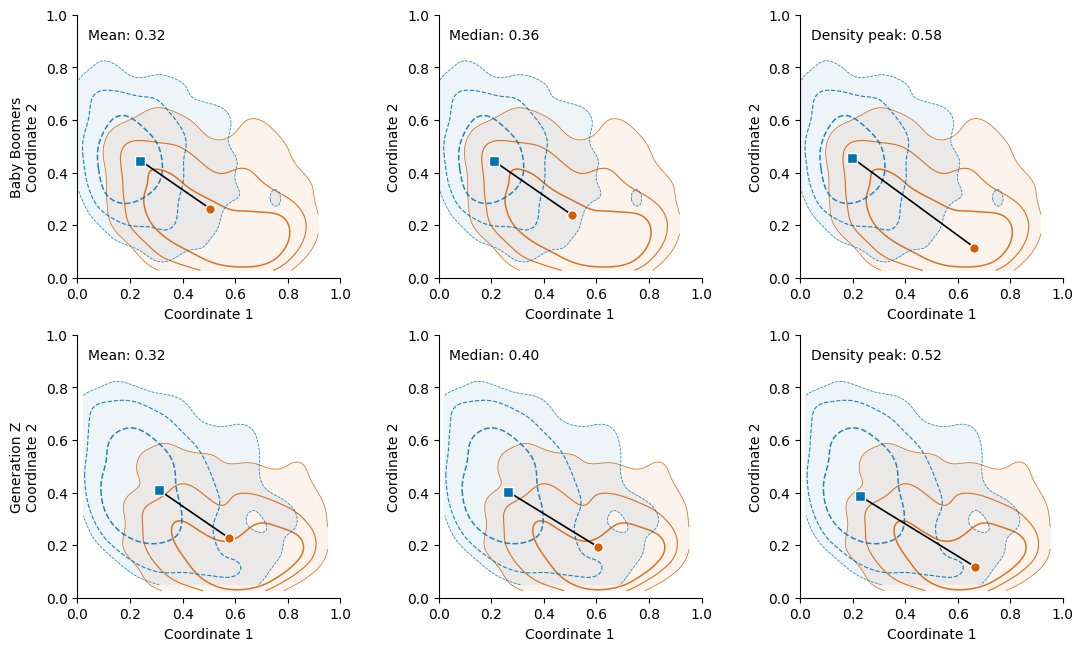

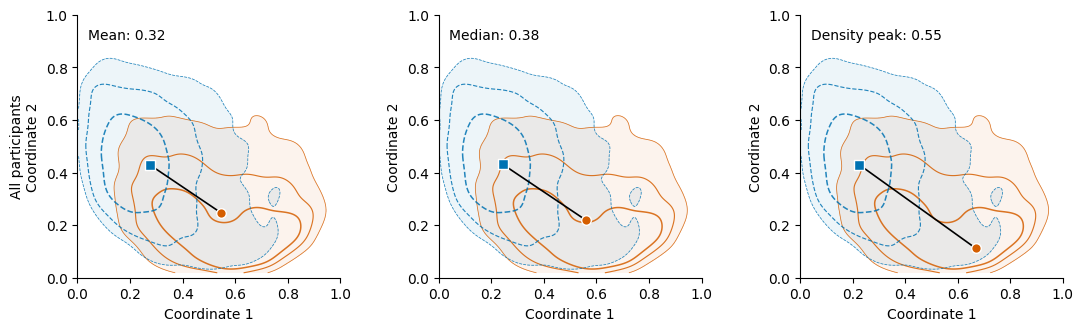

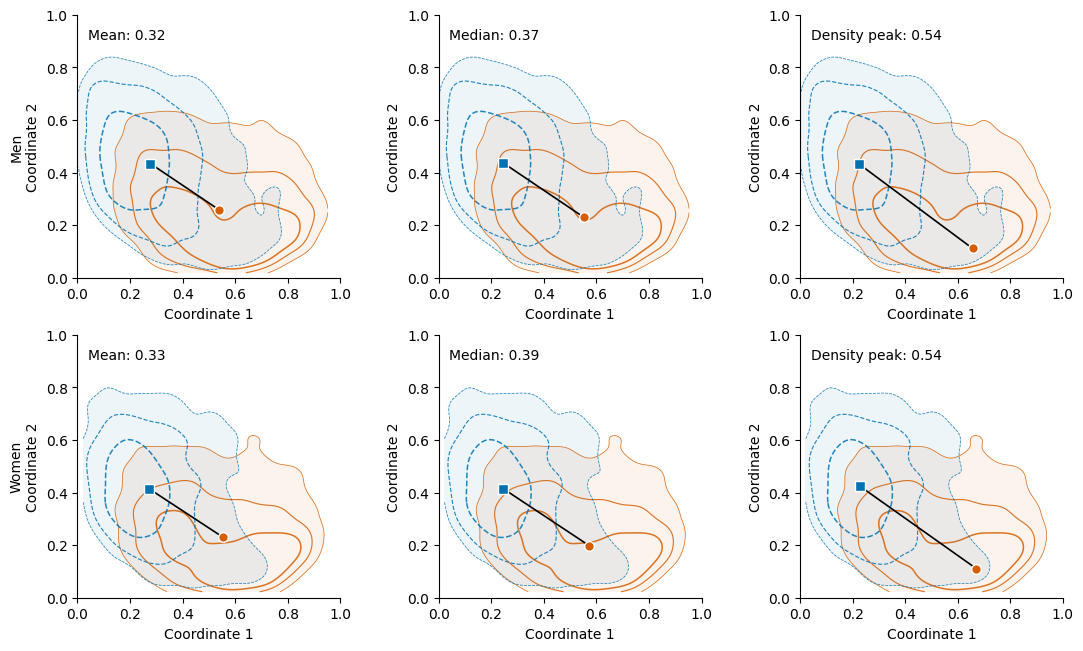

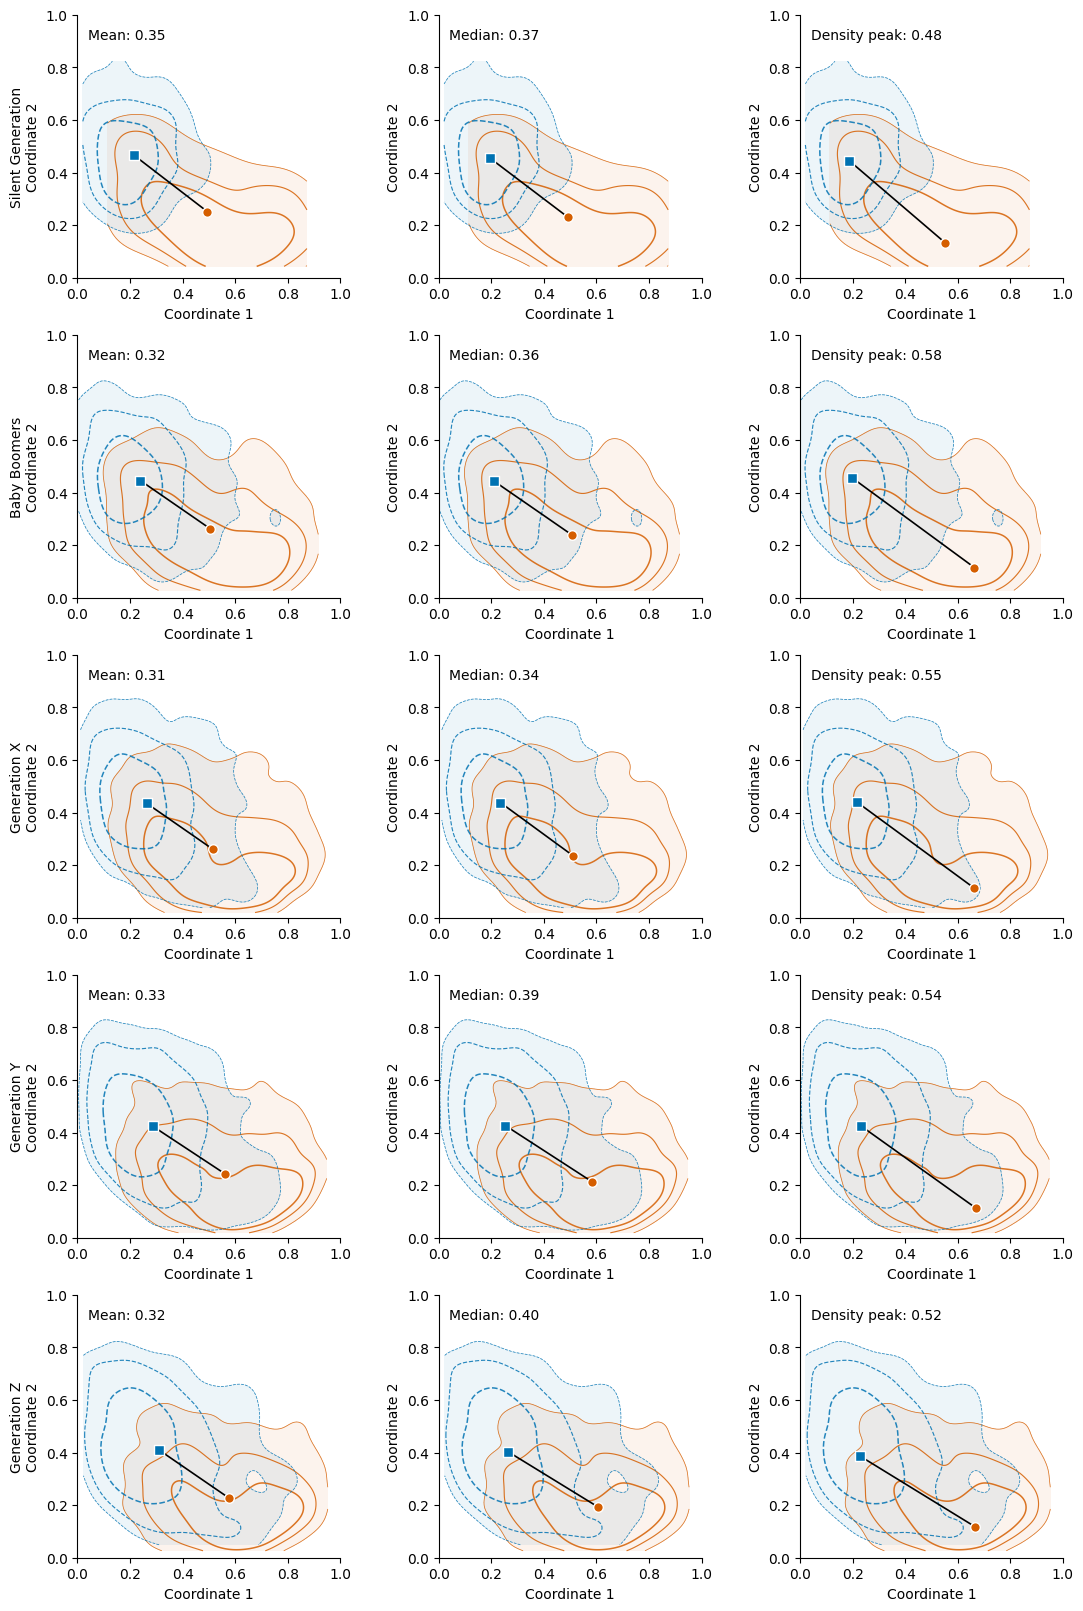

In [9]:
def summary_figure(group_names):
    fig, axes = plt.subplots(
        len(group_names),
        3,
        figsize=(11, 3.2 * len(group_names)),
        squeeze=False,
        layout="constrained",
    )
    for row, group in enumerate(group_names):
        for column, method in enumerate(["Mean", "Median", "Density peak"]):
            ax = axes[row, column]
            for side in ["Left", "Right"]:
                draw_density(ax, densities[group][side], side)
            left = densities[group]["Left"]["summaries"][method]
            right = densities[group]["Right"]["summaries"][method]
            ax.plot([left[0], right[0]], [left[1], right[1]], color="black", lw=1.2, zorder=5)
            ax.scatter(
                *left, color=COLORS["Left"], marker="o", edgecolor="white", s=48, zorder=6
            )
            ax.scatter(
                *right, color=COLORS["Right"], marker="s", edgecolor="white", s=48, zorder=6
            )
            distance = np.linalg.norm(left - right)
            ax.text(0.04, 0.95, f"{method}: {distance:.2f}", transform=ax.transAxes, va="top")
            ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Coordinate 1")
            ax.set_ylabel((group + "\n" if column == 0 else "") + "Coordinate 2")
            ax.set_aspect("equal", adjustable="box")
    return fig


for filename, group_names in [
    ("Fig4.pdf", ["Baby Boomers", "Generation Z"]),
    ("FigS10.pdf", ["All participants"]),
    ("FigS11.pdf", ["Men", "Women"]),
    ("FigS12.pdf", COHORTS),
]:
    fig = summary_figure(group_names)
    display(fig)
    fig.savefig(FIG / filename, bbox_inches="tight")
    plt.close(fig)


## Figure 5: participant distances to selected proposals

The same fitted coordinate system contains participants and proposals. `np.linalg.norm(..., axis=1)` computes one Euclidean distance per participant, using both coordinates. Distances are nonnegative even when coordinate differences are negative.

The three distance histograms share a bin width of 1/30 and a range that contains every observed distance. Their weights use the entire binary participant sample. Proposal locations and group distributions come from the same fit. No cross-country distance comparison is made here.


,participant_id,side,proposal_id,proposal,distance
0,000057c7-295c-4a61-8f62-76aff62bf079,Right,57,Human Rights,0.418889
1,00032199-2183-48c0-8f0d-ac37dc8ece60,Right,57,Human Rights,0.163401
2,000629ba-44c0-47c1-b2b2-abe4f0ee808f,Left,57,Human Rights,0.451559
3,0006b923-77a6-40c1-95e0-f98b817bcab2,Left,57,Human Rights,0.652220
4,00097f0b-7b32-4962-9780-1ca10ece1571,Right,57,Human Rights,0.604094
...,...,...,...,...,...
66124,ffdd7eff-a598-4406-b445-ee1d7b61b039,Right,55,Minimum Pension,0.194257
66125,fff04ade-6ae3-4a80-99ff-446a8bec535d,Right,55,Minimum Pension,0.082870
66126,fff8a6be-746b-4d24-9148-73c8c6accb69,Left,55,Minimum Pension,0.158322
66127,fffcdf0e-0c78-40f7-915a-d41d6650c99b,Left,55,Minimum Pension,0.615782


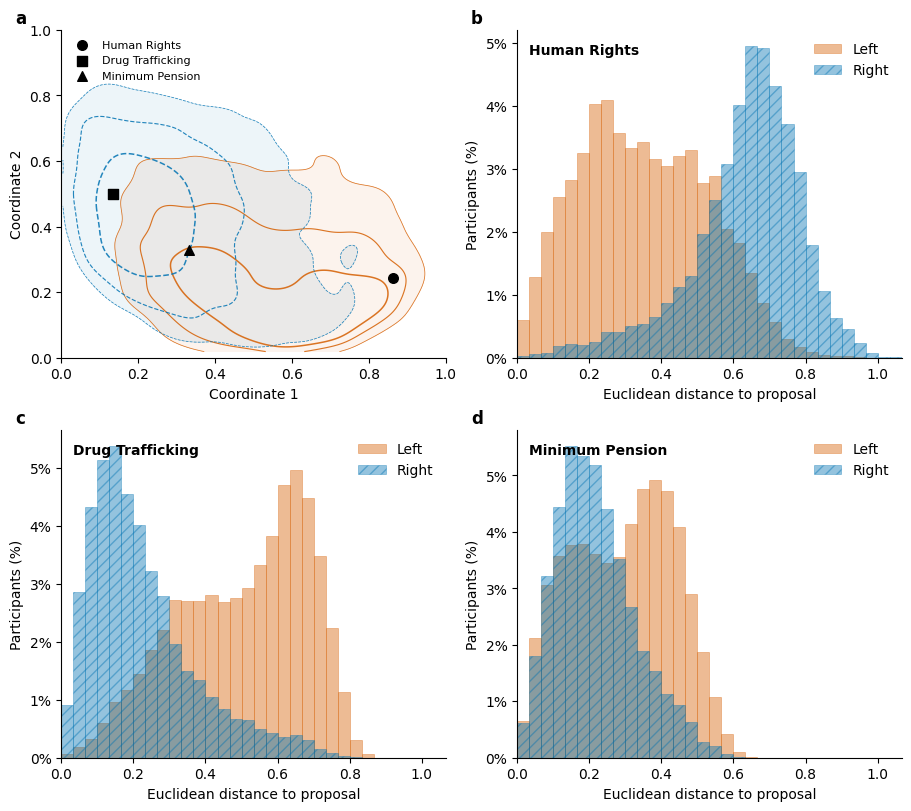

In [10]:
proposal_coordinates = pd.read_csv(DATA / "Chile_coordsP.csv")
proposal_labels = pd.read_csv(DATA / "chile_labels.tsv", sep="\t").rename(
    columns={"id": "option_id"}
)
assert proposal_coordinates.option_id.is_unique
proposals = proposal_coordinates.merge(proposal_labels, on="option_id", validate="one_to_one")
proposal_spec = [
    ("Derechos Humanos", "Human Rights", "o"),
    ("Narcotráfico", "Drug Trafficking", "s"),
    ("Pensión Mínima", "Minimum Pension", "^"),
]
people = samples[("Chile", "overall")]
fig, axes = plt.subplots(2, 2, figsize=(9, 8), layout="constrained")
axmap = axes[0, 0]
for side in ["Left", "Right"]:
    draw_density(axmap, densities["All participants"][side], side)
proposal_distance_frames = []
maximum_distance = max(
    float(
        np.linalg.norm(
            people[["z1", "z2"]].to_numpy()
            - proposals.loc[proposals.short_name == native, ["z1", "z2"]].to_numpy()[0],
            axis=1,
        ).max()
    )
    for native, _, _ in proposal_spec
)
bin_count = max(30, int(np.ceil(maximum_distance * 30)))
histogram_edges = np.arange(bin_count + 1) / 30
for (native, label, marker), ax in zip(proposal_spec, axes.flat[1:]):
    match = proposals[proposals.short_name == native]
    assert len(match) == 1, (native, len(match))
    point = match[["z1", "z2"]].to_numpy()[0]
    axmap.scatter(point[1], point[0], marker=marker, color="black", s=48, label=label, zorder=8)
    distance = np.linalg.norm(people[["z1", "z2"]].to_numpy() - point, axis=1)
    frame = people[["participant_id", "side"]].copy()
    frame["proposal_id"] = match.option_id.iloc[0]
    frame["proposal"] = label
    frame["distance"] = distance
    proposal_distance_frames.append(frame)
    assert distance.min() >= 0
    # Use a common bin width of 1/30 and extend the range to include
    # every observed distance, including values above one.
    for side in ["Left", "Right"]:
        values = frame.loc[frame.side == side, "distance"]
        ax.hist(
            values,
            bins=histogram_edges,
            weights=np.ones(len(values)) / len(frame),
            color=COLORS[side],
            edgecolor=COLORS[side],
            alpha=0.42,
            hatch=None if side == "Left" else "///",
            label=side,
            linewidth=0.55,
        )
    ax.text(0.03, 0.96, label, transform=ax.transAxes, va="top", fontweight="bold")
    ax.set(
        xlim=(0, histogram_edges[-1]),
        xlabel="Euclidean distance to proposal",
        ylabel="Participants (%)",
    )
    ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
    ax.legend(frameon=False, loc="upper right")
axmap.set(xlim=(0, 1), ylim=(0, 1), xlabel="Coordinate 1", ylabel="Coordinate 2")
axmap.legend(frameon=False, loc="upper left", fontsize=8)
for label, ax in zip("abcd", axes.flat):
    ax.text(-0.12, 1.02, label, transform=ax.transAxes, fontweight="bold", fontsize=12)
proposal_distances = pd.concat(proposal_distance_frames, ignore_index=True)
display(proposal_distances)
proposal_distances.to_csv(OUT / "participant_proposal_distances.csv", index=False)
display(fig)
fig.savefig(FIG / "Fig5.pdf", bbox_inches="tight")
plt.close(fig)


## Figure 2c: joint participant–proposal map

The five proposals with the strongest relative ranking in each self-reported group receive that group's color and marker. The other 80 remain gray. These colors describe comparative support in notebook 06, not a label used to estimate proposal coordinates.

The cutoff and disjoint-set checks prevent ambiguous top-five assignments. The resulting table records which proposals received each color. Density contours reuse the full Chilean binary participant sample above.


,option_id,z1,z2,short_name,name,topic_name,ranking_izquierda_sort,ranking_derecha_sort,highlight_side,highlight_rank
0,1,0.663117,0.460457,Farmacias,Creación de Farmacias Populares,Salud,0.750000,1.333333,Other,<NA>
1,2,0.977909,0.769293,Marihuana,Legalización de la Marihuana,Salud,0.944444,1.058824,Other,<NA>
2,3,0.331054,0.274275,Cárcel Cohecho,Cárcel Efectiva para Soborno y Cohecho,Política Criminal,0.625000,1.600000,Other,<NA>
3,4,0.545465,0.685188,Retiro AFP,Retiro Anticipado Fondo de Pensiones,Pensiones,0.745455,1.341463,Other,<NA>
4,5,0.739270,0.115391,Más Metro,Crear Nuevas Líneas de Metro,Vivienda y Transporte,1.925000,0.519481,Other,<NA>
...,...,...,...,...,...,...,...,...,...,...
85,86,0.381413,0.672768,CAE,Condonación de las deudas del Crédito con Aval...,Educación,0.380000,2.631579,Other,<NA>
86,87,0.370188,0.254616,Sueldo Mínimo,Aumentar el Sueldo Mínimo,Laboral,0.368421,2.714286,Other,<NA>
87,88,0.350024,0.830478,Plebiscitos Nacionales,Habilitar plebiscitos nacionales.,Democracia,0.324324,3.083333,Other,<NA>
88,89,0.293969,0.046756,Autonomía Regional,Entregar más autonomía a las regiones en su go...,Modernización del Estado,1.057143,0.945946,Other,<NA>


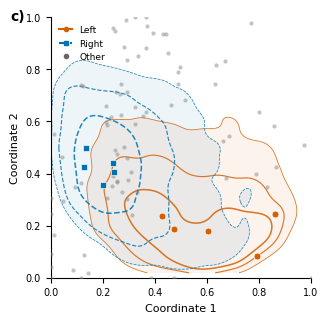

In [11]:
from matplotlib.lines import Line2D

# Highlight five proposals per side using the relative TrueSkill
# rankings. Labels interpret the fitted map.
ranking = pd.read_csv(DATA / "Ranking_propuestas_trueskill_primerciclo.csv").rename(
    columns={"id": "option_id"}
)
rank_columns = {"Left": "ranking_izquierda_sort", "Right": "ranking_derecha_sort"}
assert ranking.option_id.is_unique
proposal_colors = proposals.merge(
    ranking[["option_id"] + list(rank_columns.values())],
    on="option_id",
    how="left",
    validate="one_to_one",
)
assert len(proposal_colors) == len(proposals) == 90
assert proposal_colors[list(rank_columns.values())].notna().all().all()
proposal_colors["highlight_side"] = "Other"
proposal_colors["highlight_rank"] = pd.Series(pd.NA, index=proposal_colors.index, dtype="Int64")
selected_ids = {}
for side, column in rank_columns.items():
    ordered = proposal_colors.sort_values(column, ascending=True)
    assert ordered.iloc[4][column] < ordered.iloc[5][column], "Tie at top-five cutoff"
    selected_ids[side] = ordered.head(5).option_id.tolist()
    for rank, identifier in enumerate(selected_ids[side], 1):
        mask = proposal_colors.option_id.eq(identifier)
        assert proposal_colors.loc[mask, "highlight_side"].eq("Other").all()
        proposal_colors.loc[mask, "highlight_side"] = side
        proposal_colors.loc[mask, "highlight_rank"] = rank
assert set(selected_ids["Left"]).isdisjoint(selected_ids["Right"])
assert proposal_colors.highlight_side.value_counts().to_dict() == {
    "Other": 80,
    "Left": 5,
    "Right": 5,
}
display(proposal_colors)
proposal_colors.to_csv(OUT / "fig2c_proposal_colors.csv", index=False)
fig, ax = plt.subplots(figsize=(3.17, 3.14), layout="constrained")
for side in ["Left", "Right"]:
    draw_density(ax, densities["All participants"][side], side)
other = proposal_colors[proposal_colors.highlight_side == "Other"]
ax.scatter(other.z2, other.z1, s=9, color="#888888", alpha=0.5, linewidths=0, zorder=7)
for side, marker in [("Left", "o"), ("Right", "s")]:
    selected = proposal_colors[proposal_colors.highlight_side == side]
    ax.scatter(
        selected.z2,
        selected.z1,
        s=24,
        color=COLORS[side],
        marker=marker,
        edgecolors="white",
        linewidths=0.45,
        zorder=8,
    )
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Coordinate 1", ylabel="Coordinate 2")
ax.tick_params(labelsize=7)
ax.xaxis.label.set_size(8)
ax.yaxis.label.set_size(8)
ax.set_aspect("equal", adjustable="box")
handles = [
    Line2D([0], [0], color=COLORS["Left"], ls="-", marker="o", markersize=3, label="Left"),
    Line2D([0], [0], color=COLORS["Right"], ls="--", marker="s", markersize=3, label="Right"),
    Line2D([0], [0], color="#666666", marker="o", ls="", markersize=3, label="Other"),
]
ax.legend(handles=handles, frameon=False, fontsize=6.5, loc="upper left", handlelength=1.5)
fig.text(0.015, 0.99, "c)", ha="left", va="top", fontweight="bold", fontsize=10)
display(fig)
fig.savefig(PANELS / "Fig2c.pdf", bbox_inches="tight")
plt.close(fig)
